# Inspect simulated scan data (`SimulateScanPlugin`)

Phase-1 simulation: a deterministic, unity-gain antenna-temperature TOD (Kelvin) that
replaces `scan_data.visibility`. Components: beam-convolved Galactic foreground (Simeer) +
atmospheric + spillover + receiver + noise-diode temperatures.

This notebook loads the stored context and checks the result is physically sensible.

In [1]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from museek.enums.result_enum import ResultEnum

plt.rcParams["figure.figsize"] = [12, 5]
plt.rcParams["font.size"] = 11

# --- parameters ---
context_folder = "/home/mgrsantos/projects/data/context"
block_name = "1675021905"
pickle_name = "simulate_scan_plugin.pickle"

pickle_path = Path(context_folder) / block_name / pickle_name
print("Loading:", pickle_path, "| exists:", pickle_path.exists())

Loading: /home/mgrsantos/projects/data/context/1675021905/simulate_scan_plugin.pickle | exists: True


In [2]:
with open(pickle_path, "rb") as f:
    ctx = pickle.load(f)
scan_data = ctx.get(ResultEnum.SCAN_DATA).result

vis = np.asarray(scan_data.visibility.array).real        # (n_time, n_freq, n_recv) in Kelvin
freq_MHz = scan_data.frequencies.squeeze / 1e6
ts = scan_data.timestamps.squeeze
t_min = (ts - ts[0]) / 60.0
receivers = [r.name for r in scan_data.receivers]

# noise-diode-on mask (per dump)
flag_names = scan_data.flags.flag_names
nd_on = np.zeros(vis.shape[0], dtype=bool)
if "noise_diode_on" in flag_names:
    nd_on = np.asarray(
        scan_data.flags.get(freq=0, recv=0).array[flag_names.index("noise_diode_on")]
    ).squeeze().astype(bool)

print("vis shape:", vis.shape, "| receivers:", receivers)
print("frequencies:", f"{freq_MHz.min():.1f} - {freq_MHz.max():.1f} MHz ({len(freq_MHz)} ch)")
print("duration:", f"{t_min[-1]:.1f} min ({len(t_min)} dumps)")

vis shape: (2975, 4096, 6) | receivers: ['m000h', 'm000v', 'm005h', 'm005v', 'm023h', 'm023v']
frequencies: 544.0 - 1087.9 MHz (4096 ch)
duration: 103.5 min (2975 dumps)


## 1. Sanity-check summary

In [3]:
band = (freq_MHz > 600) & (freq_MHz < 950)   # clean mid-band for stats

print(f"finite: {np.isfinite(vis).all()} | NaNs: {int(np.isnan(vis).sum())}")
print(f"global range: [{vis.min():.2f}, {vis.max():.2f}] K, median {np.median(vis):.2f} K")
print()
if nd_on.any():
    on_T = vis[nd_on][:, band, 0].mean()
    off_T = vis[~nd_on][:, band, 0].mean()
    print(f"noise diode: {int(nd_on.sum())}/{len(nd_on)} on-dumps | "
          f"T(on)={on_T:.2f} K  T(off)={off_T:.2f} K  excess={on_T - off_T:.2f} K")
print()
print(f"{'receiver':>8} | {'mid-band median [K]':>20} | {'off-dump baseline [K]':>22}")
for i, name in enumerate(receivers):
    base = np.median(vis[~nd_on][:, band, i]) if nd_on.any() else np.median(vis[:, band, i])
    print(f"{name:>8} | {np.median(vis[:, band, i]):>20.2f} | {base:>22.2f}")

finite: True | NaNs: 0


global range: [6.28, 30.22] K, median 12.60 K



noise diode: 379/2975 on-dumps | T(on)=19.86 K  T(off)=12.04 K  excess=7.82 K

receiver |  mid-band median [K] |  off-dump baseline [K]


   m000h |                11.98 |                  11.89


   m000v |                12.38 |                  12.31


   m005h |                12.63 |                  12.55


   m005v |                13.07 |                  12.97


   m023h |                12.63 |                  12.55


   m023v |                13.13 |                  13.03


## 2. Waterfall (time × frequency)

Expect a smooth beam-convolved foreground drift, RFI-free (this is a pure simulation), with
the band edges sitting at the receiver-model extrapolation level and periodic noise-diode stripes.

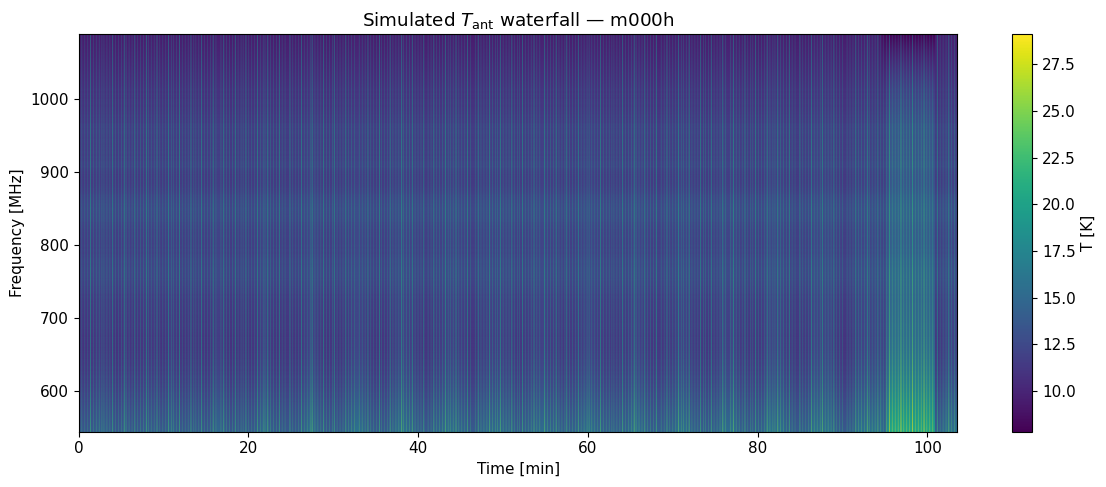

In [4]:
i_recv = 0   # index into `receivers`

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(vis[:, :, i_recv].T, aspect="auto", origin="lower",
               extent=[t_min[0], t_min[-1], freq_MHz.min(), freq_MHz.max()], cmap="viridis")
ax.set_xlabel("Time [min]")
ax.set_ylabel("Frequency [MHz]")
ax.set_title(f"Simulated $T_{{\\rm ant}}$ waterfall — {receivers[i_recv]}")
plt.colorbar(im, label="T [K]")
plt.tight_layout()
plt.show()

## 2b. Waterfall — noise-diode OFF dumps only

Same as above but excluding the `noise_diode_on` dumps, so the periodic diode stripes are
removed and the underlying foreground / system-temperature drift is easier to see.
(Columns are the off-dumps in time order; the brief ND-on gaps are dropped.)

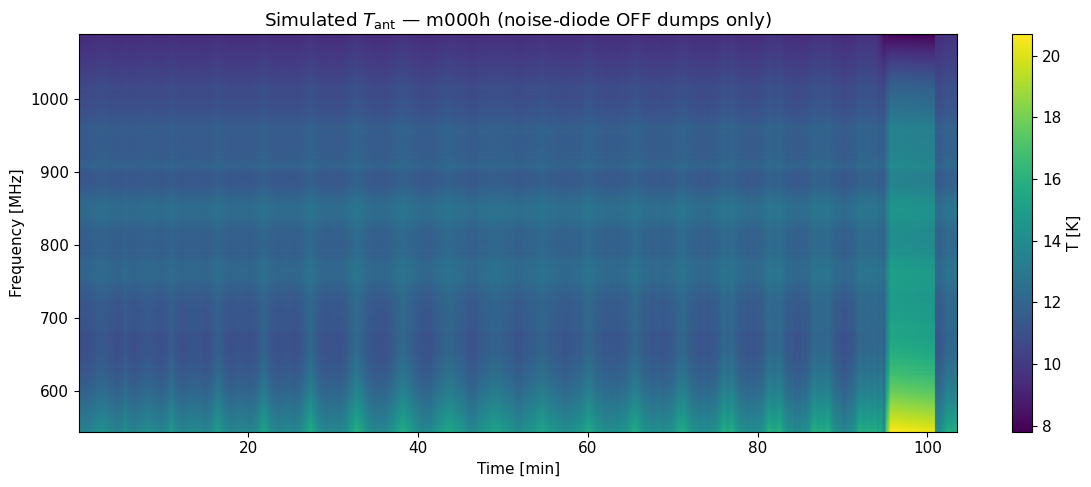

In [5]:
i_recv = 0
vis_off = vis[~nd_on, :, i_recv]          # (n_off, n_freq)
time_off = t_min[~nd_on]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(vis_off.T, aspect="auto", origin="lower",
               extent=[time_off[0], time_off[-1], freq_MHz.min(), freq_MHz.max()], cmap="viridis")
ax.set_xlabel("Time [min]")
ax.set_ylabel("Frequency [MHz]")
ax.set_title(f"Simulated $T_{{\\rm ant}}$ — {receivers[i_recv]} (noise-diode OFF dumps only)")
plt.colorbar(im, label="T [K]")
plt.tight_layout()
plt.show()

## 2c. Residual waterfall — per-frequency time median subtracted, flags masked (ND off)

Diode-off dumps only, with each frequency channel's time-**median** (over unflagged samples)
subtracted and the combined flags applied (masked pixels in grey). Removing the median (rather
than the mean) is robust to outlier dumps and leaves a residual whose per-channel time median is
zero by construction (verified in 2d).

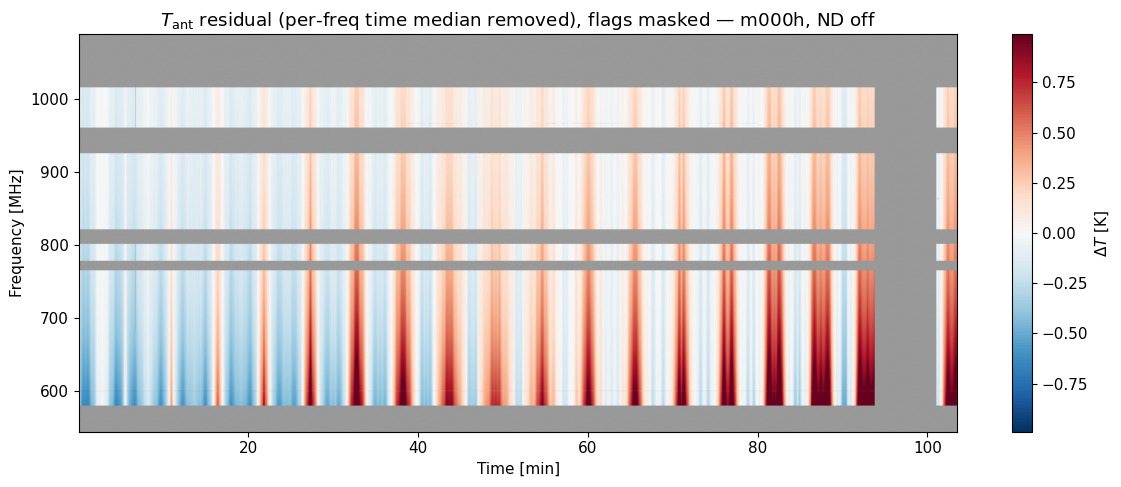

masked fraction (ND-off): 37.3%


In [6]:
i_recv = 0
off = ~nd_on

# combined flags for this receiver (band-edge/known RFI, rawdata, elevation/outlier, ...)
flags = np.asarray(scan_data.flags.combine(threshold=1).get(recv=i_recv).squeeze).astype(bool)  # (n_time, n_freq)

vis_off = np.ma.masked_array(vis[off, :, i_recv], mask=flags[off])   # (n_off, n_freq), masked
time_med = np.ma.median(vis_off, axis=0)                             # per-freq time median over UNflagged samples
resid = vis_off - time_med[np.newaxis, :]
time_off = t_min[off]

vlim = np.percentile(np.abs(resid.compressed()), 99)                 # robust symmetric scale (unmasked only)
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad("0.6")                                                  # masked pixels in grey

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(resid.T, aspect="auto", origin="lower",
               extent=[time_off[0], time_off[-1], freq_MHz.min(), freq_MHz.max()],
               cmap=cmap, vmin=-vlim, vmax=vlim)
ax.set_xlabel("Time [min]")
ax.set_ylabel("Frequency [MHz]")
ax.set_title(f"$T_{{\\rm ant}}$ residual (per-freq time median removed), flags masked \u2014 {receivers[i_recv]}, ND off")
plt.colorbar(im, label="$\\Delta T$ [K]")
plt.tight_layout()
plt.show()

print(f"masked fraction (ND-off): {resid.mask.mean()*100:.1f}%")

## 2d. RMS over time per frequency — all receivers

For each receiver: RMS over time (diode-off, unflagged) of the per-frequency median-subtracted
residual, as a spectrum. Measures how much each channel varies in time — the amplitude of the
pointing-driven foreground drift per frequency, with the static bandpass removed.

m000h: median time-RMS across band = 0.243 K


m000v: median time-RMS across band = 0.242 K


m005h: median time-RMS across band = 0.243 K


m005v: median time-RMS across band = 0.242 K


m023h: median time-RMS across band = 0.243 K


m023v: median time-RMS across band = 0.242 K


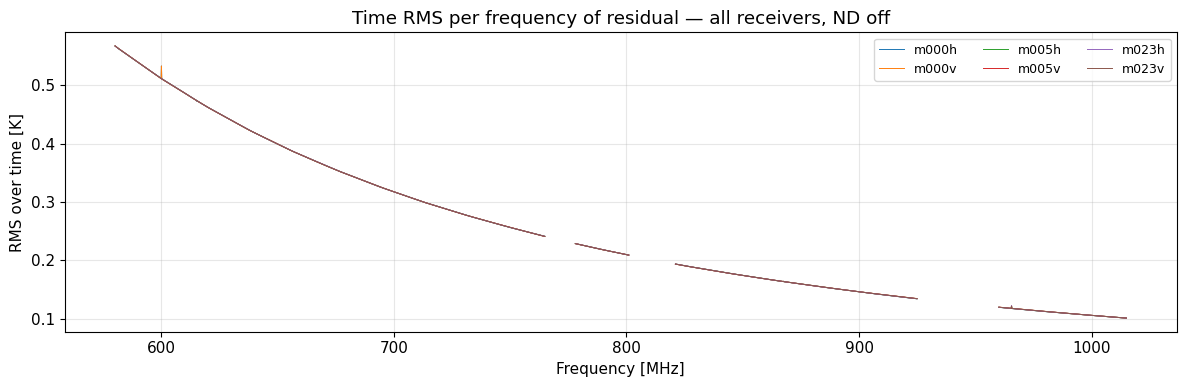

In [7]:
off = ~nd_on
all_flags = scan_data.flags.combine(threshold=1)

fig, ax = plt.subplots(figsize=(12, 4))
for i, name in enumerate(receivers):
    fl = np.asarray(all_flags.get(recv=i).squeeze).astype(bool)         # (n_time, n_freq)
    v = np.ma.masked_array(vis[off, :, i], mask=fl[off])
    r = v - np.ma.median(v, axis=0)[np.newaxis, :]                      # per-freq time median removed
    rms_time = np.ma.sqrt(np.ma.mean(r**2, axis=0))                     # (n_freq,) RMS over time
    ax.plot(freq_MHz, np.ma.filled(rms_time, np.nan), lw=0.7, label=name)
    print(f"{name}: median time-RMS across band = {np.ma.median(rms_time):.3f} K")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel(r"RMS over time [K]")
ax.set_title("Time RMS per frequency of residual \u2014 all receivers, ND off")
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Spectra at a few times

Smooth synchrotron + system temperature; the dips/rises at the band edges are the
receiver/noise-diode model extrapolation (580–1015 MHz model vs 544–1088 MHz band).

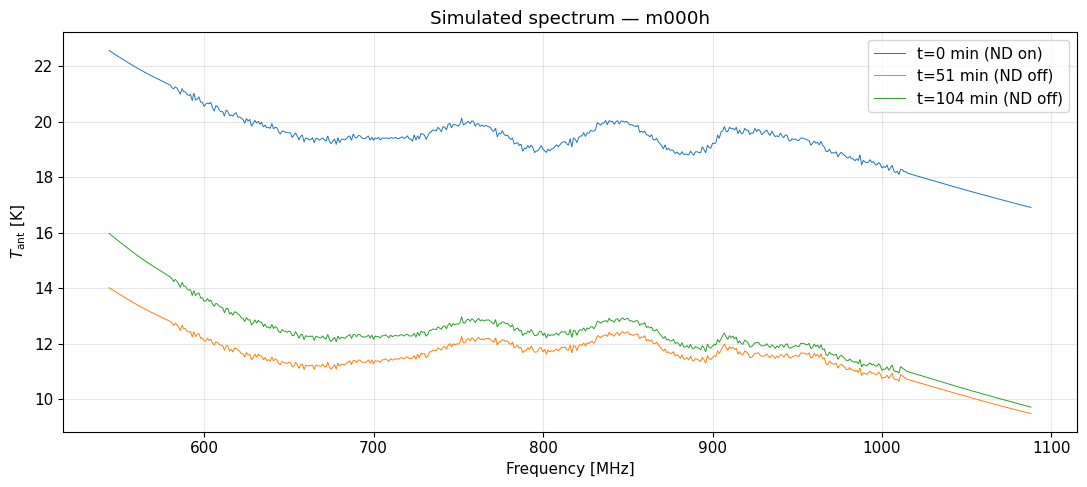

In [8]:
i_recv = 0
fig, ax = plt.subplots(figsize=(11, 5))
for t in [0, vis.shape[0] // 2, vis.shape[0] - 1]:
    tag = "ND on" if nd_on[t] else "ND off"
    ax.plot(freq_MHz, vis[t, :, i_recv], lw=0.7, label=f"t={t_min[t]:.0f} min ({tag})")
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("$T_{\\rm ant}$ [K]")
ax.set_title(f"Simulated spectrum — {receivers[i_recv]}")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Time series + noise-diode injection

Median over the clean mid-band vs time. The red points are `noise_diode_on` dumps and should
sit a clear step above the baseline; the baseline itself drifts with pointing/elevation.

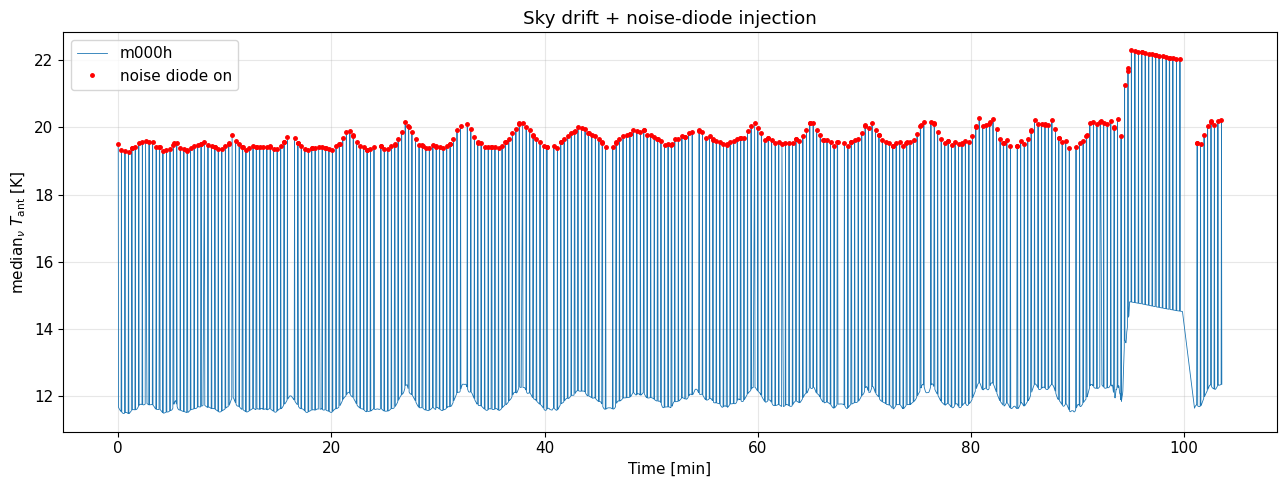

In [9]:
i_recv = 0
series = np.median(vis[:, band, i_recv], axis=1)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(t_min, series, lw=0.6, color="C0", label=receivers[i_recv])
ax.plot(t_min[nd_on], series[nd_on], ".", ms=5, color="red", label="noise diode on")
ax.set_xlabel("Time [min]")
ax.set_ylabel(r"median$_\nu$ $T_{\rm ant}$ [K]")
ax.set_title("Sky drift + noise-diode injection")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4b. Median over frequency (diode OFF) vs time — all receivers

One curve per receiver: the median over all frequency channels at each `noise_diode_on == False`
dump. With the diode dumps removed this traces the foreground/system-temperature drift; the
per-receiver offsets are the different receiver temperatures.

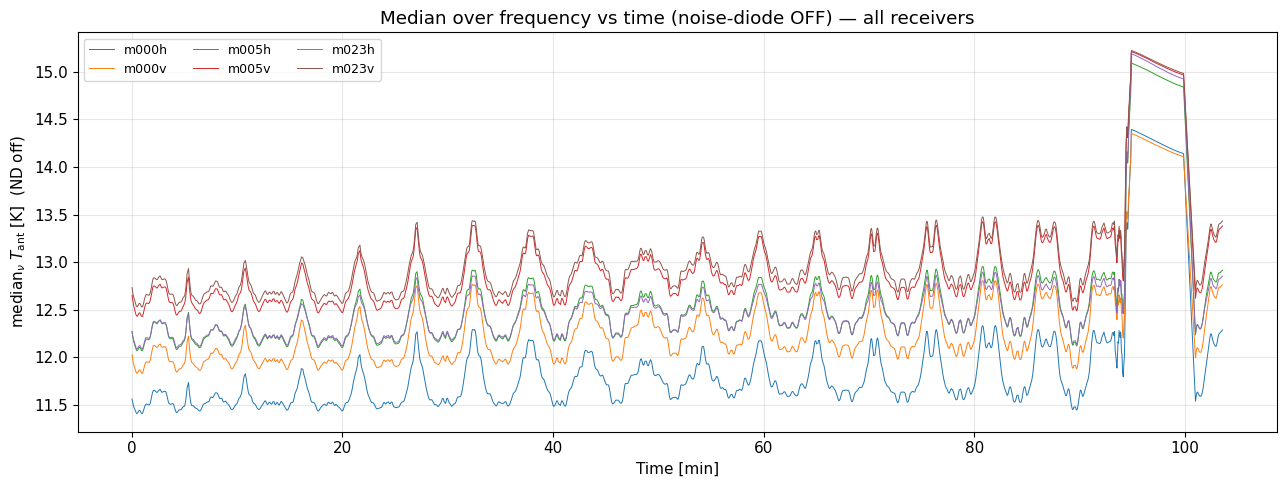

In [10]:
time_off = t_min[~nd_on]

fig, ax = plt.subplots(figsize=(13, 5))
for i, name in enumerate(receivers):
    med_off = np.median(vis[~nd_on, :, i], axis=1)   # median over freq, ND-off dumps
    ax.plot(time_off, med_off, lw=0.7, label=name)
ax.set_xlabel("Time [min]")
ax.set_ylabel(r"median$_\nu$ $T_{\rm ant}$ [K]  (ND off)")
ax.set_title("Median over frequency vs time (noise-diode OFF) \u2014 all receivers")
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4c. Median$_\nu$ $T_{\rm ant}$ (diode OFF) with elevation overlaid

Same median-over-frequency curves, with the pointing **elevation** (dashed, right axis) on top.
This makes clear that temperature excursions (e.g. the bump near ~95–100 min) track pointing
changes — here a slew to the **zenith** (el ≈ 90°) and back, rather than normal el ≈ 40° scanning.

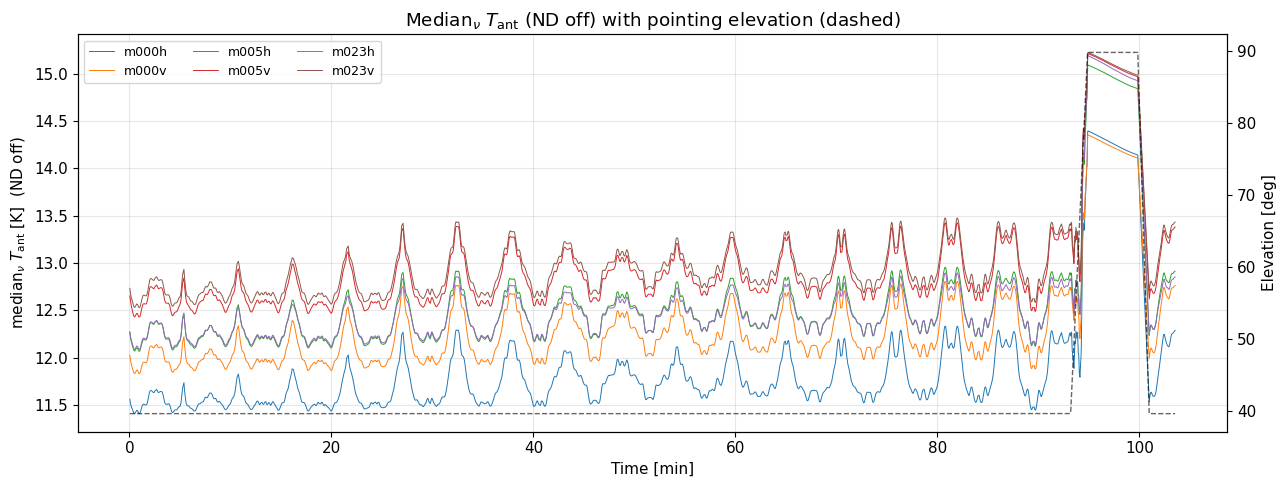

In [11]:
from museek.plugin.point_source_calibration_plugin import (
    calculate_median_coordinates_excluding_flagged_antennas,
)

_, el_deg = calculate_median_coordinates_excluding_flagged_antennas(scan_data)
time_off = t_min[~nd_on]

fig, ax = plt.subplots(figsize=(13, 5))
for i, name in enumerate(receivers):
    ax.plot(time_off, np.median(vis[~nd_on, :, i], axis=1), lw=0.7, label=name)
ax.set_xlabel("Time [min]")
ax.set_ylabel(r"median$_\nu$ $T_{\rm ant}$ [K]  (ND off)")
ax.grid(alpha=0.3)

ax2 = ax.twinx()
ax2.plot(time_off, el_deg[~nd_on], "k--", lw=1.0, alpha=0.6)
ax2.set_ylabel("Elevation [deg]")

ax.set_title("Median$_\\nu$ $T_{\\rm ant}$ (ND off) with pointing elevation (dashed)")
ax.legend(ncol=3, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

## 4d. Per-dish elevation vs time (median sanity check)

Raw elevation of each individual dish, with the median (used by the simulation) dashed on top.
All dishes move together to the zenith and back — the per-dump spread across dishes is < 0.6°
over the whole observation — so the ~95–100 min excursion is a real coordinated pointing, not
an artifact of the median calculation.

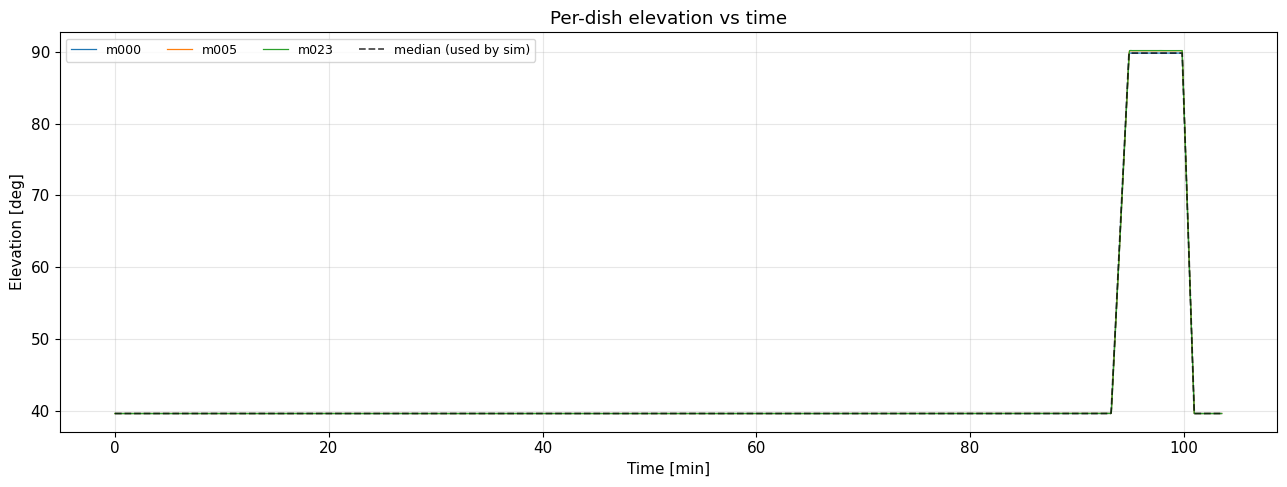

max per-dump spread across dishes: 0.594 deg


In [12]:
from museek.plugin.point_source_calibration_plugin import (
    calculate_median_coordinates_excluding_flagged_antennas,
)

el_data = np.asarray(scan_data.elevation.squeeze)        # (n_time, n_antennas)
antennas = [a.name for a in scan_data.antennas]
_, el_med = calculate_median_coordinates_excluding_flagged_antennas(scan_data)

fig, ax = plt.subplots(figsize=(13, 5))
for i, name in enumerate(antennas):
    ax.plot(t_min, el_data[:, i], lw=0.9, label=name)
ax.plot(t_min, el_med, "k--", lw=1.3, alpha=0.7, label="median (used by sim)")
ax.set_xlabel("Time [min]")
ax.set_ylabel("Elevation [deg]")
ax.set_title("Per-dish elevation vs time")
ax.legend(ncol=4, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("max per-dump spread across dishes:", f"{np.ptp(el_data, axis=1).max():.3f} deg")

## 4e. Applying the flags — `elevation_flag` removes the zenith excursion

`antenna_flagger` **does** flag the zenith dumps (`elevation_flag` = 100% there, 0% on the normal
scan). The simulation writes a value for every dump regardless of flags, so the excursion only
shows because the earlier plots don't apply the flags. Here we mask `vis` with the combined flags
and take the median over *unflagged* channels — the ~95–100 min bump becomes a gap, confirming it
is correctly flagged.

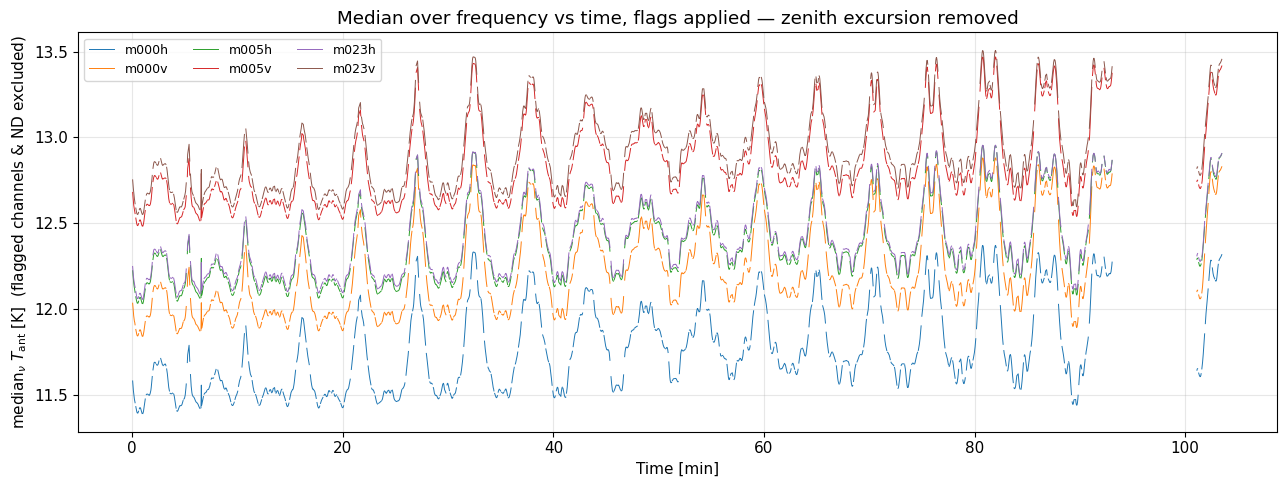

elevation_flag covers 7.0% of dumps


In [13]:
all_flags = scan_data.flags.combine(threshold=1)   # combined boolean flags (n_time, n_freq, n_recv)
time_off = t_min[~nd_on]

fig, ax = plt.subplots(figsize=(13, 5))
for i, name in enumerate(receivers):
    fl = np.asarray(all_flags.get(recv=i).squeeze).astype(bool)        # (n_time, n_freq)
    masked = np.ma.masked_array(vis[:, :, i], mask=fl)
    med = np.ma.median(masked, axis=1)                                 # masked where the whole dump is flagged
    med = np.ma.masked_where(nd_on, med)                               # also drop noise-diode dumps
    ax.plot(t_min, med, lw=0.7, label=name)
ax.set_xlabel("Time [min]")
ax.set_ylabel(r"median$_\nu$ $T_{\rm ant}$ [K]  (flagged channels & ND excluded)")
ax.set_title("Median over frequency vs time, flags applied \u2014 zenith excursion removed")
ax.legend(ncol=3, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

elev = np.asarray(scan_data.flags.get(recv=0).array[scan_data.flags.flag_names.index("elevation_flag")]).squeeze()
print("elevation_flag covers", f"{elev.astype(bool).any(axis=1).mean()*100:.1f}%", "of dumps")

## 5. Per-receiver comparison & noise-diode excess spectrum

Left: off-dump mean spectrum per receiver (receiver-temperature differences show here).
Right: the noise-diode excess spectrum `T(on) - T(off)` — should match duty×T_nd.

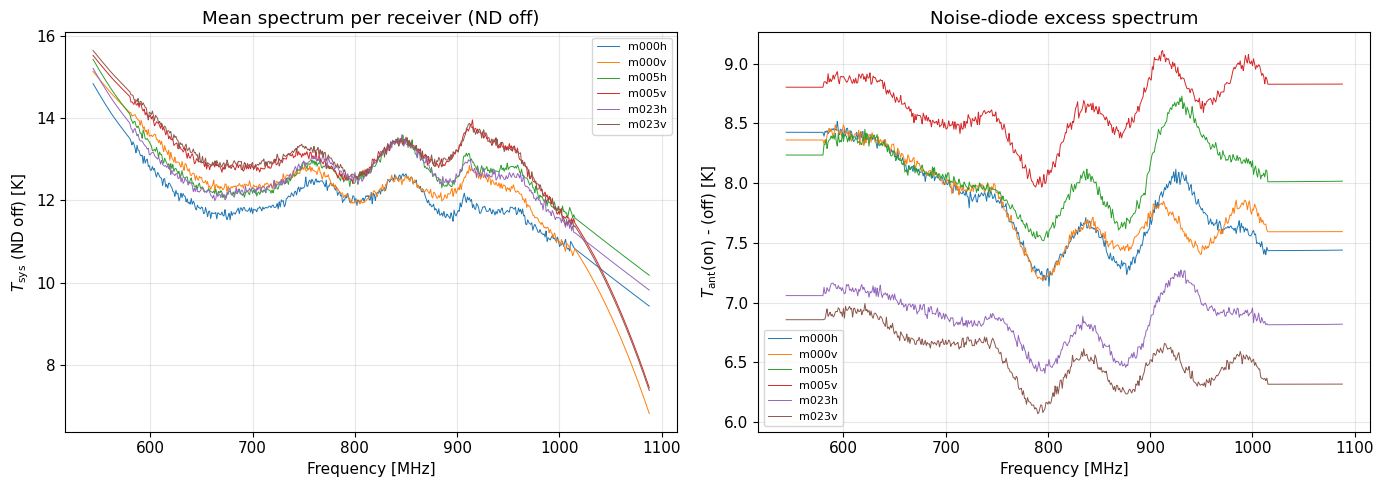

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, name in enumerate(receivers):
    off_spec = vis[~nd_on][:, :, i].mean(axis=0) if nd_on.any() else vis[:, :, i].mean(axis=0)
    axes[0].plot(freq_MHz, off_spec, lw=0.7, label=name)
axes[0].set_xlabel("Frequency [MHz]"); axes[0].set_ylabel(r"$T_{\rm sys}$ (ND off) [K]")
axes[0].set_title("Mean spectrum per receiver (ND off)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

if nd_on.any():
    for i, name in enumerate(receivers):
        excess = vis[nd_on][:, :, i].mean(axis=0) - vis[~nd_on][:, :, i].mean(axis=0)
        axes[1].plot(freq_MHz, excess, lw=0.7, label=name)
    axes[1].set_xlabel("Frequency [MHz]"); axes[1].set_ylabel(r"$T_{\rm ant}$(on) - (off) [K]")
    axes[1].set_title("Noise-diode excess spectrum"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()